# EDA — MultiCite (`classification_3_context`)

**Proyecto:** *Recomendación local de citas y clasificación de su función en artículos académicos* (Uniandes, FLAG–TICsW) · **Micro-proyecto PDS — Entrega 1**

Este cuaderno cubre tres puntos del reporte: la **descripción del conjunto de datos**, la **exploración de los datos (EDA)** y la **construcción de los conjuntos de datos** que usará el resto del equipo. El sub-proyecto trabaja únicamente con el subconjunto `classification_3_context` de **MultiCite**; por tratarse de un subconjunto del esfuerzo completo, la meta de balance se ajusta de 2.000 a **700 ejemplos por categoría**.


In [43]:
import json, re, math, hashlib, warnings, urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})

BASE = ("https://raw.githubusercontent.com/allenai/multicite/master/"
        "data/classification_3_context/")
DATA_DIR = Path("./data_cache"); DATA_DIR.mkdir(exist_ok=True)
OUT_DIR  = Path("./eda_out");    OUT_DIR.mkdir(exist_ok=True)
SEED = 42

def fetch(fname: str) -> Path:
    """Descarga con cache local."""
    dest = DATA_DIR / fname
    if dest.exists() and dest.stat().st_size > 0:
        print(f"  {fname}: cache ({dest.stat().st_size/1e6:.2f} MB)")
        return dest
    print(f"  {fname}: descargando ...", end=" ", flush=True)
    urllib.request.urlretrieve(BASE + fname, dest)
    print(f"{dest.stat().st_size/1e6:.2f} MB")
    return dest

print("listo |", DATA_DIR)

listo | data_cache


---
# Dataset MultiCite

## 1.1 Descripción

**MultiCite** (Lauscher *et al.*, NAACL 2022; arXiv:2107.00414) es la mayor colección de contextos de cita anotados por expertos: **1.200 pares citante–citado** de lingüística computacional (ACL Anthology), anotados sobre el **texto completo** del artículo citante. Su tesis —que da título al paper— es que modelar citas reales exige salir del supuesto "una oración, una etiqueta": los contextos reales abarcan varias oraciones y una misma cita puede cumplir **varias funciones a la vez**. Licencia **CC BY-NC 2.0** (uso no comercial, compatible con este proyecto académico). Repo: https://github.com/allenai/multicite

Además del release completo (texto integral por oraciones), el repositorio publica versiones **listas para clasificación**: `classification_<k>_context`, donde `x` es una **ventana de k oraciones alrededor de la mención** de la cita (`k = 1` es solo la oración que cita; `gold_context` es el contexto dorado anotado, de longitud variable). Este cuaderno usa **k = 3** (la oración de la cita ± 1 oración), por tres razones:

1. Es la granularidad más cercana al *citation context* de la propuesta: una ventana corta y de tamaño fijo alrededor del marcador de cita.
2. El punto medio entre la oración sola (pierde el contexto que motiva la anotación multi-oración de MultiCite) y el contexto dorado (longitud impredecible para el presupuesto de tokens).
3. A diferencia del release completo, ya entrega pares *(texto, etiqueta)* con **particiones oficiales aisladas por documento** — nos ahorra reconstruir contextos.

## 1.2 Estructura de los datos

Cada partición es un JSON con una lista de registros `{id, x, y}`:

| campo | tipo | contenido |
|---|---|---|
| `id` | str | `<id_del_par>_<consecutivo>`: el prefijo identifica el **par citante–citado**; el sufijo numera las instancias del par |
| `x` | str | ventana de **3 oraciones**; la mención del artículo objetivo va envuelta en `<cite>…</cite>`; algunos textos arrastran encabezados de sección del texto completo, con la forma `**INTRODUCTION**` |
| `y` | str | una o varias etiquetas de intent **separadas por espacio** (p. ej. `"similarities uses"`) — así serializa el release el carácter multi-etiqueta |

In [44]:
SPLITS = ["train", "dev", "test"]
raw = {s: json.loads(fetch(f"{s}.json").read_text()) for s in SPLITS}
for s in SPLITS:
    print(f"{s:<6} {len(raw[s]):>6,} instancias")
print(f"TOTAL  {sum(len(v) for v in raw.values()):>6,}")

  train.json: cache (3.11 MB)
  dev.json: cache (1.43 MB)
  test.json: cache (1.85 MB)
train   5,491 instancias
dev     2,447 instancias
test    3,313 instancias
TOTAL  11,251


In [45]:
def peek(rec, max_chars=900):
    print(json.dumps(rec, indent=2, ensure_ascii=False)[:max_chars]); print("-" * 88)

print("Registro tipico (una sola etiqueta):\n")
peek(raw["train"][0])

multi = next(r for r in raw["train"] if len(r["y"].split()) > 1)
print("Registro multi-etiqueta (y = etiquetas separadas por espacio):\n")
peek(multi)

con_sec = next(r for r in raw["train"]
               if isinstance(r["x"], str) and "**" in r["x"] and "<cite>" in r["x"])
print("Registro con encabezado de seccion embebido (**MAYUSCULAS**):\n")
peek(con_sec)

Registro tipico (una sola etiqueta):

{
  "id": "021c423c731ecbe3e26b3ce234b390_0",
  "x": "Automatic detection of fake from legitimate news in different formats such as headlines, tweets and full news articles has been approached in recent Natural Language Processing literature (Vlachos and Riedel, 2014; Vosoughi, 2015; Jin et al., 2016;<cite> Rashkin et al., 2017</cite>; Wang, 2017; Pomerleau and Rao, 2017; Thorne et al., 2018) . The most important challenge in automatic misinformation detection using modern NLP techniques, especially at the level of full news articles, is data. Most previous systems built to identify fake news articles rely on training data labeled with respect to the general reputation of the sources, i.e., domains/user accounts (Fogg et al., 2001; Lazer et al., 2017;<cite> Rashkin et al., 2017)</cite> .",
  "y": "background"
}
----------------------------------------------------------------------------------------
Registro multi-etiqueta (y = etiquetas separadas p

Normalizamos a un `DataFrame` único: se desempaquetan los pocos `x` que vienen como lista (rareza del release), se separan las etiquetas, se deriva el **par citante–citado** del `id` y se agregan longitud, número de marcadores `<cite>` y un hash del texto (se usa en 1.8).

In [46]:
CITE = re.compile(r"<cite>")
rows = []
for s in SPLITS:
    for r in raw[s]:
        x = r["x"][0] if isinstance(r["x"], list) else r["x"]   # algunos vienen como lista
        labs = r["y"].split()
        rows.append(dict(
            split_orig=s, inst_id=r["id"], pair_id=r["id"].rsplit("_", 1)[0],
            context=x.strip(), y_raw=r["y"], labels=labs, n_labels=len(labs),
            n_words=len(x.split()), n_cites=len(CITE.findall(x))))
df = pd.DataFrame(rows)
df["ctx_hash"] = (df.context.str.lower().str.replace(r"\W+", " ", regex=True).str.strip()
                    .map(lambda t: hashlib.md5(t.encode()).hexdigest()[:16]))

n_list = sum(isinstance(r["x"], list) for s in SPLITS for r in raw[s])
print(f"{len(df):,} instancias | {df.pair_id.nunique():,} pares citante-citado unicos")
print(f"Anomalias del release: {n_list} registros con `x` empaquetado en lista "
      f"(se desempaquetan) y {(df.n_cites == 0).sum()} instancias sin marcador <cite>.")
df.head(3)[["split_orig", "inst_id", "pair_id", "y_raw", "n_labels", "n_words", "n_cites"]]

11,251 instancias | 1,196 pares citante-citado unicos
Anomalias del release: 72 registros con `x` empaquetado en lista (se desempaquetan) y 71 instancias sin marcador <cite>.


,split_orig,inst_id,pair_id,y_raw,n_labels,n_words,n_cites
0,train,021c423c731ecbe3e26b3ce234b390_0,021c423c731ecbe3e26b3ce234b390,background,1,113,2
1,train,021c423c731ecbe3e26b3ce234b390_1,021c423c731ecbe3e26b3ce234b390,motivation,1,105,1
2,train,021c423c731ecbe3e26b3ce234b390_2,021c423c731ecbe3e26b3ce234b390,background,1,64,1


## 1.3 Tamaño y particiones originales

MultiCite publica sus propios `train` / `dev` / `test`, particionados por par citante–citado: todas las instancias de un mismo par viven en la misma partición, para evitar fuga de datos.

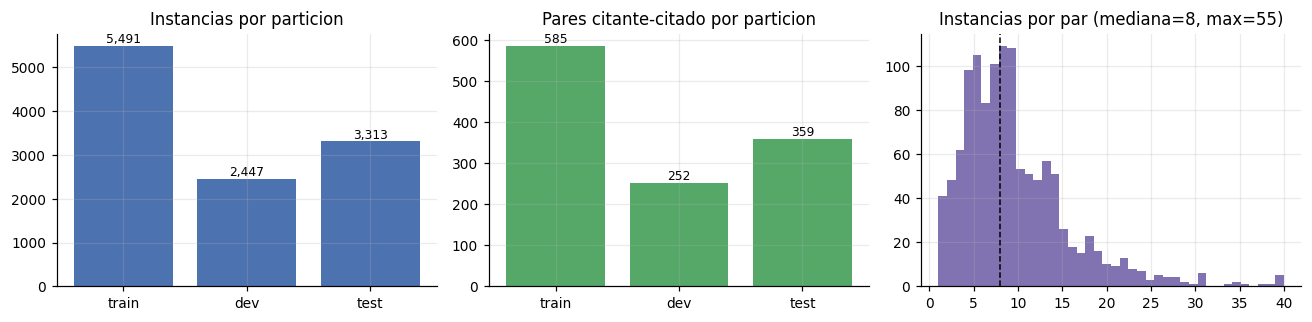

Pares compartidos entre particiones: {'train ∩ dev': 0, 'train ∩ test': 0, 'dev ∩ test': 0}  <- todos deben ser 0
Aislamiento por documento verificado: ningun par citante-citado cruza particiones.


In [47]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
vc = df.split_orig.value_counts().reindex(SPLITS)
ax[0].bar(vc.index, vc.values, color="#4C72B0")
for i, v in enumerate(vc.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax[0].set_title("Instancias por particion")

pares = df.groupby("split_orig").pair_id.nunique().reindex(SPLITS)
ax[1].bar(pares.index, pares.values, color="#55A868")
for i, v in enumerate(pares.values):
    ax[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax[1].set_title("Pares citante-citado por particion")

per_par = df.groupby("pair_id").size()
ax[2].hist(per_par.clip(0, 40), bins=40, color="#8172B2")
ax[2].axvline(per_par.median(), ls="--", color="k", lw=1)
ax[2].set_title(f"Instancias por par (mediana={per_par.median():.0f}, max={per_par.max()})")
plt.tight_layout();
plt.savefig("Distribución de conjuntos de train test.png")
plt.show()

sets = {s: set(df[df.split_orig == s].pair_id) for s in SPLITS}
solapes = {f"{a} ∩ {b}": len(sets[a] & sets[b])
           for a, b in [("train", "dev"), ("train", "test"), ("dev", "test")]}
print("Pares compartidos entre particiones:", solapes, " <- todos deben ser 0")
assert all(v == 0 for v in solapes.values()), "hay fuga entre particiones!"
print("Aislamiento por documento verificado: ningun par citante-citado cruza particiones.")

## 1.4 Clases originales: los 7 *intents* de MultiCite

| intent | qué marca la anotación |
|---|---|
| `background` | la cita aporta contexto o información general del tema |
| `motivation` | la cita justifica o motiva la necesidad del trabajo citante |
| `uses` | el citante usa un método, dato, herramienta o recurso del citado |
| `extends` | el citante extiende, adapta o modifica lo propuesto en el citado |
| `similarities` | se señala una similitud entre el citante y el citado |
| `differences` | se señala una diferencia o contraste con el citado |
| `future_work` | el citado se menciona como parte del trabajo futuro |

(El intent `unsure` del release completo no aparece en las versiones de clasificación.) Como una instancia puede llevar varios intents, la distribución se reporta **expandida**: cada instancia cuenta una vez por cada etiqueta que porta.

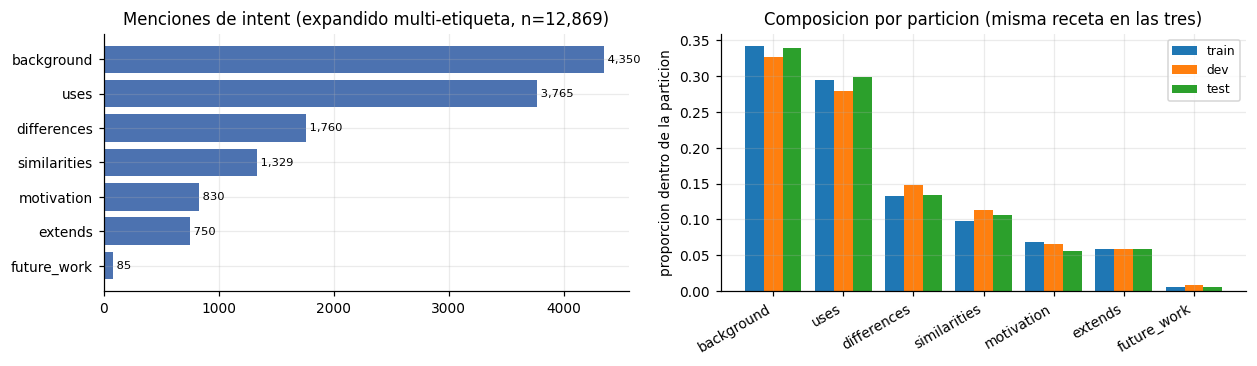

split_orig,train,dev,test,TOTAL
intent,,,,
background,2144,929,1277,4350
uses,1848,793,1124,3765
differences,836,420,504,1760
similarities,609,322,398,1329
motivation,433,185,212,830
extends,365,165,220,750
future_work,37,25,23,85


In [48]:
exp = df.explode("labels").rename(columns={"labels": "intent"}).reset_index(drop=True)
INTENTS = exp.intent.value_counts().index.tolist()          # orden por frecuencia

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.4))
vc = exp.intent.value_counts()
ax[0].barh(vc.index[::-1], vc.values[::-1], color="#4C72B0")
for i, v in enumerate(vc.values[::-1]):
    ax[0].text(v, i, f" {v:,}", va="center", fontsize=7.5)
ax[0].set_title(f"Menciones de intent (expandido multi-etiqueta, n={vc.sum():,})")

prop = pd.crosstab(exp.intent, exp.split_orig, normalize="columns")[SPLITS].loc[INTENTS]
x = np.arange(len(INTENTS)); w = .27
for k, s in enumerate(SPLITS):
    ax[1].bar(x + (k - 1) * w, prop[s].values, width=w, label=s)
ax[1].set_xticks(x, INTENTS, rotation=30, ha="right")
ax[1].set_ylabel("proporcion dentro de la particion"); ax[1].legend(fontsize=8)
ax[1].set_title("Composicion por particion (misma receta en las tres)")
plt.tight_layout();
plt.savefig("clases originales.png")
plt.show()

tab = pd.crosstab(exp.intent, exp.split_orig)[SPLITS].loc[INTENTS]
tab["TOTAL"] = tab.sum(axis=1)
display(tab)

In [49]:
def entropia_norm(vc):
    p = vc / vc.sum()
    return float(-(p * np.log(p)).sum() / np.log(len(p))) if len(p) > 1 else 0.0

filas = []
for nombre, g in [("GLOBAL", exp)] + [(s, exp[exp.split_orig == s]) for s in SPLITS]:
    vc = g.intent.value_counts()
    filas.append(dict(particion=nombre, k_clases=len(vc), mayoritaria=vc.index[0],
                      pct_mayoritaria=f"{vc.iloc[0]/vc.sum():.1%}",
                      minoritaria=vc.index[-1], n_min=int(vc.iloc[-1]),
                      ratio_desbalance=f"{vc.iloc[0]/vc.iloc[-1]:.0f}:1",
                      entropia_norm=round(entropia_norm(vc), 3)))
display(pd.DataFrame(filas).set_index("particion"))
print("entropia_norm: 1.0 = balance perfecto, 0 = colapso en una sola clase.")

,k_clases,mayoritaria,pct_mayoritaria,minoritaria,n_min,ratio_desbalance,entropia_norm
particion,,,,,,,
GLOBAL,7,background,33.8%,future_work,85,51:1,0.827
train,7,background,34.2%,future_work,37,58:1,0.823
dev,7,background,32.7%,future_work,25,37:1,0.841
test,7,background,34.0%,future_work,23,56:1,0.819


entropia_norm: 1.0 = balance perfecto, 0 = colapso en una sola clase.


## 1.5 Multi-etiqueta y co-ocurrencia de intents

La seña de identidad de MultiCite: una fracción relevante de los contextos porta **más de una función a la vez**. El número que salga de aquí decide un punto de la guía de anotación del proyecto (A3): selección única (*radio buttons*) o múltiple (*checkboxes*).

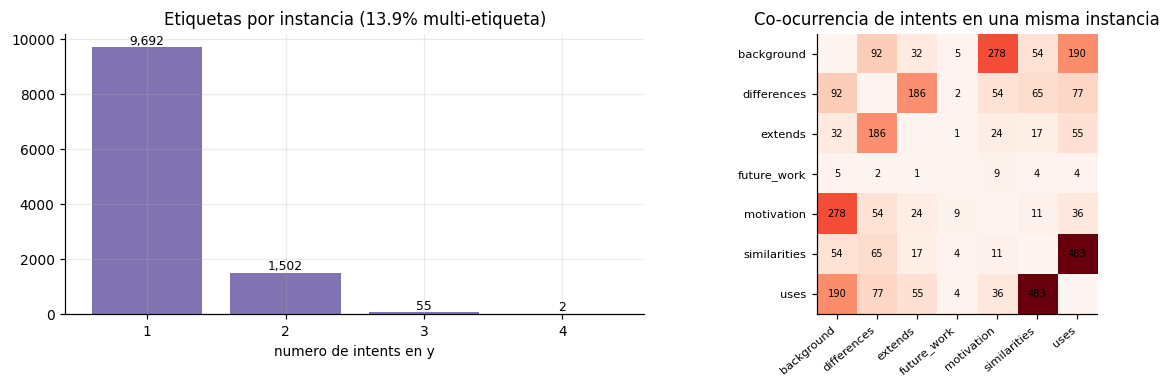

Multi-etiqueta por particion: train: 13.6% | dev: 15.7% | test: 13.0%

Pares que mas co-ocurren (fronteras difusas del esquema):


,intent_A,intent_B,co_ocurrencias
0,similarities,uses,483
1,background,motivation,278
2,background,uses,190
3,differences,extends,186
4,background,differences,92
5,differences,uses,77


In [50]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
vc = df.n_labels.value_counts().sort_index()
ax[0].bar(vc.index.astype(str), vc.values, color="#8172B2")
for i, v in enumerate(vc.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax[0].set_title(f"Etiquetas por instancia ({(df.n_labels > 1).mean():.1%} multi-etiqueta)")
ax[0].set_xlabel("numero de intents en y")

labs = sorted(set(l for L in df.labels for l in L))
co = pd.DataFrame(0, index=labs, columns=labs)
for L in df.labels:
    u = sorted(set(L))
    for i in range(len(u)):
        for j in range(i + 1, len(u)):
            co.loc[u[i], u[j]] += 1; co.loc[u[j], u[i]] += 1
ax[1].imshow(co.values, cmap="Reds"); ax[1].grid(False)
ax[1].set_xticks(range(len(labs)), labs, rotation=40, ha="right", fontsize=7.5)
ax[1].set_yticks(range(len(labs)), labs, fontsize=7.5)
for i in range(len(labs)):
    for j in range(len(labs)):
        if co.values[i, j]:
            ax[1].text(j, i, co.values[i, j], ha="center", va="center", fontsize=6.5)
ax[1].set_title("Co-ocurrencia de intents en una misma instancia")
plt.tight_layout(); plt.show()

print("Multi-etiqueta por particion: " +
      " | ".join(f"{s}: {(df[df.split_orig == s].n_labels > 1).mean():.1%}" for s in SPLITS))
pares_co = [(a, b, int(co.loc[a, b])) for i, a in enumerate(labs) for b in labs[i + 1:]]
print("\nPares que mas co-ocurren (fronteras difusas del esquema):")
display(pd.DataFrame(sorted(pares_co, key=lambda t: -t[2])[:6],
                     columns=["intent_A", "intent_B", "co_ocurrencias"]))

## 1.6 Longitud del contexto

Cuánto texto entra por instancia. Es el insumo directo del presupuesto de entrada del clasificador de A4: SciBERT admite 512 tokens de subpalabra (≈ 380 palabras de inglés científico), y todo lo que sobre se trunca en silencio. El boxplot por intent verifica además que ninguna clase tenga contextos sistemáticamente más largos, porque truncar la perjudicaría selectivamente.

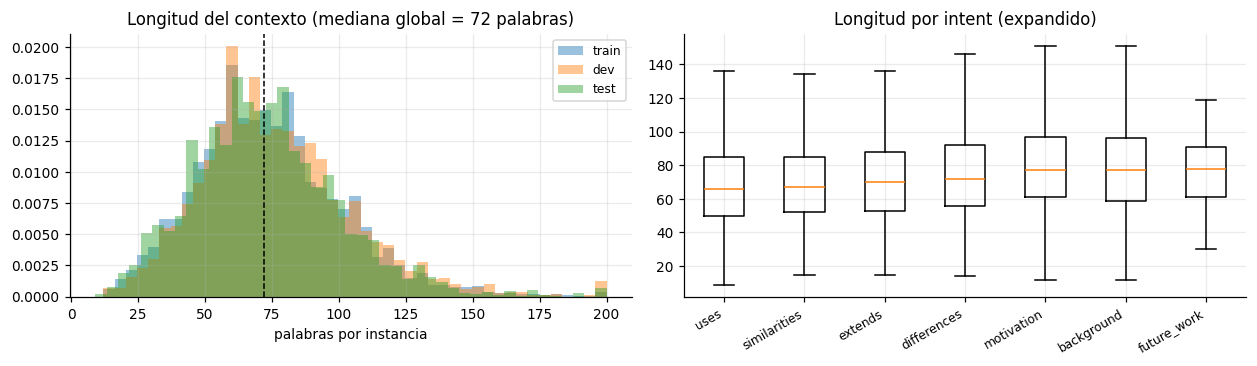

Cuantiles de longitud (palabras): {'p5': 33, 'p25': 55, 'p50': 72, 'p75': 90, 'p95': 123, 'p99': 157}
Marcadores <cite> por instancia (5 = cinco o mas): {0: 71, 1: 8466, 2: 2016, 3: 469, 4: 135, 5: 94}

La ventana tipica de 3 oraciones ronda las 60-70 palabras; la cola larga viene de
oraciones cientificas extensas y de ventanas que absorben material de tablas/figuras.
Una instancia puede contener varios <cite> cuando el objetivo se menciona mas de
una vez dentro de la ventana.


In [51]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.4))
for s in SPLITS:
    ax[0].hist(df[df.split_orig == s].n_words.clip(0, 200), bins=45,
               alpha=.45, density=True, label=s)
ax[0].axvline(df.n_words.median(), ls="--", color="k", lw=1)
ax[0].set_xlabel("palabras por instancia"); ax[0].legend(fontsize=8)
ax[0].set_title(f"Longitud del contexto (mediana global = {df.n_words.median():.0f} palabras)")

orden = exp.groupby("intent").n_words.median().sort_values().index.tolist()
ax[1].boxplot([exp[exp.intent == t].n_words.clip(0, 220) for t in orden],
              showfliers=False)
ax[1].set_xticks(range(1, len(orden) + 1), orden, rotation=30, ha="right", fontsize=8)
ax[1].set_title("Longitud por intent (expandido)")
plt.tight_layout(); plt.show()

q = df.n_words.quantile([.05, .25, .5, .75, .95, .99]).round(0).astype(int)
print("Cuantiles de longitud (palabras):",
      dict(zip(["p5", "p25", "p50", "p75", "p95", "p99"], q)))
vc_c = df.n_cites.clip(0, 5).value_counts().sort_index()
print("Marcadores <cite> por instancia (5 = cinco o mas):",
      {int(k): int(v) for k, v in vc_c.items()})
print("\nLa ventana tipica de 3 oraciones ronda las 60-70 palabras; la cola larga viene de")
print("oraciones cientificas extensas y de ventanas que absorben material de tablas/figuras.")
print("Una instancia puede contener varios <cite> cuando el objetivo se menciona mas de")
print("una vez dentro de la ventana.")

## 1.7 Sección retórica embebida en la ventana

Al extraer las ventanas desde el texto completo, el release arrastra algunos **encabezados de sección** como texto con formato `**MAYÚSCULAS**`. No son una columna de metadatos, pero permiten *derivar* la sección para el subconjunto de instancias cuya ventana incluye un encabezado antes del ``.

Con eso se mide cuánto informa la sección sobre la función de la cita. La tabla `P(intent | sección)` se lee por filas —"de todas las citas que aparecen en Introduction, ¿qué fracción es background?"— y la **información mutua** resume en un número cuánta incertidumbre elimina conocer la sección. La cifra es orientativa y no un estimado insesgado: la señal solo se observa en cerca del 11% de las instancias, y esas no son una muestra aleatoria del corpus sino las que caen justo al inicio de una sección.

Instancias con algun encabezado **X** en la ventana: 13.3%
Instancias con seccion ASIGNABLE (encabezado antes del <cite>): 11.4%  (n=1,281)


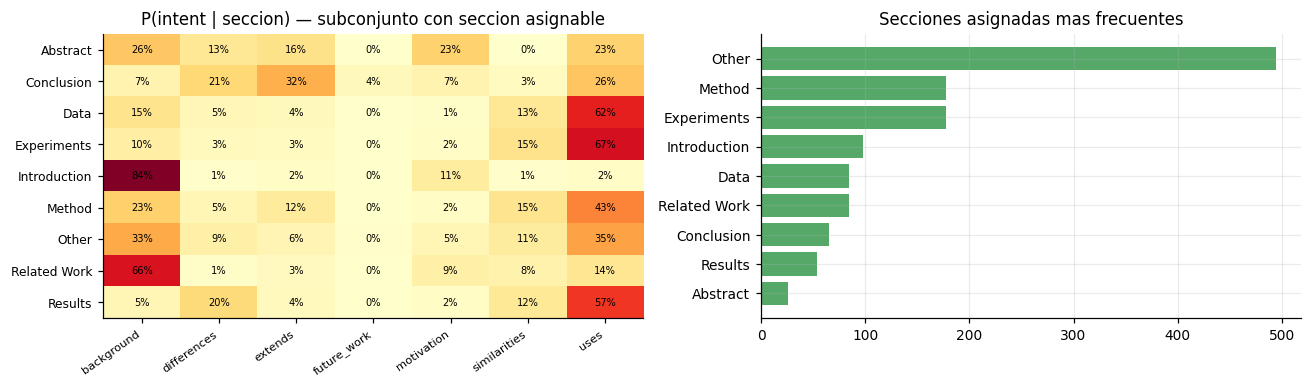

H(intent) = 2.190 bits | H(intent|seccion) = 1.929 bits | informacion mutua = 0.260 bits (11.9% de reduccion)
Ojo: la senal solo se observa en ~1 de cada 10 instancias del release;
en el pipeline propio (A1) la seccion se registrara para todos los chunks.


In [52]:
SEC_PAT = re.compile(r"\*\*([^*]+)\*\*")

def seccion_asignable(txt):
    """Ultimo encabezado **X** que aparece ANTES del primer <cite>."""
    pos = txt.find("<cite>")
    if pos < 0:
        return None
    prev = [m.group(1).strip() for m in SEC_PAT.finditer(txt) if m.start() < pos]
    return prev[-1] if prev else None

def canon_section(s):
    if not isinstance(s, str):
        return None
    t = re.sub(r"^[\d\.\s]+", "", s).lower().strip()
    for key, name in [("introduc", "Introduction"), ("relat", "Related Work"),
                      ("background", "Background"), ("method", "Method"),
                      ("approach", "Method"), ("model", "Method"),
                      ("experiment", "Experiments"), ("evaluat", "Experiments"),
                      ("setup", "Experiments"), ("result", "Results"),
                      ("discuss", "Discussion"), ("conclu", "Conclusion"),
                      ("abstract", "Abstract"), ("data", "Data"),
                      ("corpus", "Data"), ("task", "Method")]:
        if key in t:
            return name
    return "Other"

df["sec_raw"]   = df.context.map(seccion_asignable)
df["sec_canon"] = df.sec_raw.map(canon_section)

tiene_marca = df.context.str.contains(r"\*\*[^*]+\*\*", regex=True).mean()
print(f"Instancias con algun encabezado **X** en la ventana: {tiene_marca:.1%}")
print(f"Instancias con seccion ASIGNABLE (encabezado antes del <cite>): "
      f"{df.sec_canon.notna().mean():.1%}  (n={df.sec_canon.notna().sum():,})")

sec = df[df.sec_canon.notna()].explode("labels").rename(columns={"labels": "intent"}).reset_index(drop=True)
keep = sec.sec_canon.value_counts()
sec = sec[sec.sec_canon.isin(keep[keep >= 30].index)]
ct = pd.crosstab(sec.sec_canon, sec.intent, normalize="index")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].imshow(ct.values, cmap="YlOrRd", aspect="auto"); ax[0].grid(False)
ax[0].set_xticks(range(ct.shape[1]), ct.columns, rotation=35, ha="right", fontsize=7.5)
ax[0].set_yticks(range(ct.shape[0]), ct.index, fontsize=8)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax[0].text(j, i, f"{ct.values[i, j]:.0%}", ha="center", va="center", fontsize=6.5)
ax[0].set_title("P(intent | seccion) — subconjunto con seccion asignable")

top = df.sec_canon.value_counts().head(9)
ax[1].barh(top.index[::-1], top.values[::-1], color="#55A868")
ax[1].set_title("Secciones asignadas mas frecuentes")
plt.tight_layout(); plt.show()

py = sec.intent.value_counts(normalize=True)
H_y = -(py * np.log2(py)).sum()
H_c = sum((sec.sec_canon == s0).mean() *
          -((v := sec[sec.sec_canon == s0].intent.value_counts(normalize=True))
            * np.log2(v)).sum() for s0 in sec.sec_canon.unique())
mi_pct = float((H_y - H_c) / H_y)
print(f"H(intent) = {H_y:.3f} bits | H(intent|seccion) = {H_c:.3f} bits | "
      f"informacion mutua = {H_y - H_c:.3f} bits ({mi_pct:.1%} de reduccion)")
print("Ojo: la senal solo se observa en ~1 de cada 10 instancias del release;")
print("en el pipeline propio (A1) la seccion se registrara para todos los chunks.")

## 1.8 Duplicados e integridad del texto

In [53]:
g = df.groupby("ctx_hash")
tam = g.size()
dup_grupos  = int((tam > 1).sum())
filas_extra = int((tam - 1).clip(lower=0).sum())
cross_split = int((g.split_orig.nunique() > 1).sum())
cross_pair  = int((g.pair_id.nunique() > 1).sum())
conflicto   = int((g.y_raw.nunique() > 1).sum())

print(f"Grupos de contexto duplicado (texto normalizado): {dup_grupos:,} "
      f"({filas_extra:,} filas redundantes, {filas_extra/len(df):.1%} del total)")
print(f"  - grupos que cruzan particiones train/dev/test: {cross_split:,}  <- contaminacion del release")
print(f"  - grupos que cruzan pares citante-citado:       {cross_pair:,}")
print(f"  - grupos con etiquetas distintas: {conflicto:,}  <- la misma ventana de 3 oraciones\n"
      f"    cubre menciones anotadas con funciones diferentes (ambiguedad de la ventana)")
print()
print("Origen tipico: ventanas de 3 oraciones que se solapan alrededor de menciones")
print("cercanas del mismo objetivo. Decision para el proyecto (2.4): deduplicar por hash")
print("conservando la primera aparicion, de modo que ningun texto repetido llegue al test.")

ej = tam[tam > 1].index[0]
print("\nEjemplo de grupo duplicado:")
display(df[df.ctx_hash == ej][["split_orig", "inst_id", "y_raw", "n_words"]].head(4))

Grupos de contexto duplicado (texto normalizado): 586 (616 filas redundantes, 5.5% del total)
  - grupos que cruzan particiones train/dev/test: 20  <- contaminacion del release
  - grupos que cruzan pares citante-citado:       31
  - grupos con etiquetas distintas: 383  <- la misma ventana de 3 oraciones
    cubre menciones anotadas con funciones diferentes (ambiguedad de la ventana)

Origen tipico: ventanas de 3 oraciones que se solapan alrededor de menciones
cercanas del mismo objetivo. Decision para el proyecto (2.4): deduplicar por hash
conservando la primera aparicion, de modo que ningun texto repetido llegue al test.

Ejemplo de grupo duplicado:


,split_orig,inst_id,y_raw,n_words
935,train,2a84615479af66bbf875517a3a753b_10,uses,51
8222,test,0fd26c6dffab3fba2d120d2c58dff6_9,uses,51


---
# Parte 2 — EDA enfocado al proyecto


## 2.1 Mapeo de los 7 intents a las 9 categorías del proyecto

El esquema de clasificación del proyecto define **9 categorías** de función de cita y fija una meta de **700 ejemplos por categoría** para esta entrega, con validación humana sobre el 15% del conjunto y aislamiento por documento entre particiones. Esta parte contrasta el subconjunto de MultiCite contra esas condiciones: qué categorías cubre, cuántos ejemplos aporta cada una y qué queda fuera de alcance.

| intent MultiCite | → categoría | confianza | justificación frente a la definición de la propuesta |
|---|---|---|---|
| `background` | **Background** | exact | coincide con "contexto general / estado del campo" |
| `motivation` | **Gap** | exact | "justificar la elección del tema, señalar vacíos" ≈ motivar el trabajo |
| `similarities` | **Comparison** | exact | la categoría del proyecto abarca **explícitamente** similitudes… |
| `differences` | **Comparison** | exact | …y diferencias con los trabajos citados |
| `uses` | **Application** | partial | la propuesta exige "emplear **sin modificación**"; `uses` también cubre casos que en el esquema del proyecto caerían en *Basis* (punto de partida intelectual) |
| `extends` | **Improvement** | exact | adaptar / extender / modificar el método citado |
| `future_work` | — | none | mencionar algo como trabajo futuro **no** equivale a *FurtherReading* (dirigir al lector a literatura complementaria); además n≈85 |

Quedan **huérfanas** (cero ejemplos en MultiCite): **Basis, Evidence, Originator y FurtherReading** — solo podrán poblarse en A2. Nótese además que al fusionar `similarities` + `differences`, las instancias que traían **ambos** intents colapsan en una sola mención de *Comparison*.

In [54]:
TARGET_9 = ["Background", "Gap", "Basis", "Comparison", "Application",
            "Improvement", "Evidence", "Originator", "FurtherReading"]

MC_MAP = {  # intent MultiCite -> (categoria proyecto, confianza)
    "background":   ("Background",  "exact"),
    "motivation":   ("Gap",         "exact"),
    "similarities": ("Comparison",  "exact"),
    "differences":  ("Comparison",  "exact"),
    "uses":         ("Application", "partial"),   # conflaciona Application/Basis
    "extends":      ("Improvement", "exact"),
    "future_work":  (None,          "none"),
}

def a_targets(labels):
    return sorted({MC_MAP[l][0] for l in labels if MC_MAP[l][0]})

df["targets"]   = df.labels.map(a_targets)
df["n_targets"] = df.targets.map(len)

colapso    = sum(1 for L in df.labels if {"similarities", "differences"} <= set(L))
sin_target = int((df.n_targets == 0).sum())
print(f"Instancias con >= 1 categoria del proyecto: {(df.n_targets > 0).sum():,} de {len(df):,}")
print(f"  - {colapso} instancias traian similarities Y differences -> colapsan en un solo 'Comparison'")
print(f"  - {sin_target} instancias quedan sin categoria (solo future_work) -> se descartan")
display(df.n_targets.value_counts().sort_index().to_frame("instancias"))

Instancias con >= 1 categoria del proyecto: 11,188 de 11,251
  - 65 instancias traian similarities Y differences -> colapsan en un solo 'Comparison'
  - 63 instancias quedan sin categoria (solo future_work) -> se descartan


,instancias
n_targets,
0,63
1,9698
2,1450
3,39
4,1


## 2.2 Cobertura de las 9 categorías frente a la meta de 700

Cuántos ejemplos heredables existen por categoría objetivo y por partición. Se distinguen las instancias **"puras"** (una sola categoría del proyecto — incluye, p. ej., `similarities differences`, que colapsa en *Comparison*) del aporte **extra** de las multi-etiqueta (instancias que suman a dos o más categorías a la vez).

split_orig,train,dev,test,TOTAL,puro_total,puro_train
target,,,,,,
Background,2144,929,1277,4350,3735,1831
Gap,433,185,212,830,460,244
Basis,0,0,0,0,0,0
Comparison,1415,720,889,3024,2101,996
Application,1848,793,1124,3765,2952,1457
Improvement,365,165,220,750,450,219
Evidence,0,0,0,0,0,0
Originator,0,0,0,0,0,0
FurtherReading,0,0,0,0,0,0


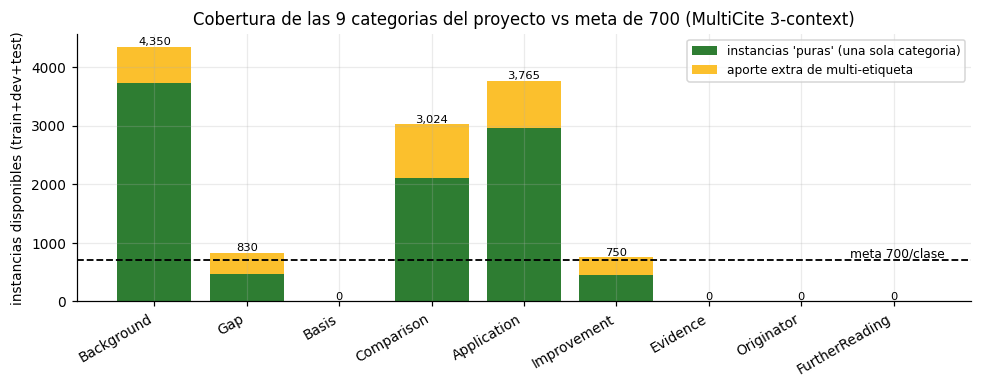

Categorias SIN ningun ejemplo en MultiCite: ['Basis', 'Evidence', 'Originator', 'FurtherReading']
Estas cuatro solo podran poblarse en A2 (mineria + pre-etiquetado con modelos abiertos).


In [55]:
META = 700
tgt_exp = (df[df.n_targets > 0].explode("targets")
           .rename(columns={"targets": "target"}).reset_index(drop=True))

cov = (tgt_exp.pivot_table(index="target", columns="split_orig",
                           values="inst_id", aggfunc="size", fill_value=0)
       .reindex(TARGET_9).fillna(0).astype(int))[SPLITS]
cov["TOTAL"] = cov.sum(axis=1)
puros = df[df.n_targets == 1].assign(target=lambda d: d.targets.str[0])
cov["puro_total"] = puros.groupby("target").size().reindex(TARGET_9).fillna(0).astype(int)
cov["puro_train"] = (puros[puros.split_orig == "train"].groupby("target").size()
                     .reindex(TARGET_9).fillna(0).astype(int))
display(cov)

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(TARGET_9))
puro  = cov["puro_total"].values
extra = (cov["TOTAL"] - cov["puro_total"]).values
ax.bar(x, puro,  label="instancias 'puras' (una sola categoria)", color="#2E7D32")
ax.bar(x, extra, bottom=puro, label="aporte extra de multi-etiqueta", color="#FBC02D")
ax.axhline(META, ls="--", lw=1.2, color="k")
ax.text(len(x) - .45, META * 1.08, f"meta {META}/clase", ha="right", fontsize=8)
for i in range(len(x)):
    tot = puro[i] + extra[i]
    ax.text(i, tot, f"{tot:,}" if tot else "0", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(x, TARGET_9, rotation=30, ha="right")
ax.set_ylabel("instancias disponibles (train+dev+test)")
ax.legend(fontsize=8)
ax.set_title("Cobertura de las 9 categorias del proyecto vs meta de 700 (MultiCite 3-context)")
plt.tight_layout();
plt.savefig('mapeo_a_nuevas_clases.png')
plt.show()

huerfanas = [c for c in TARGET_9 if cov.loc[c, "TOTAL"] == 0]
print(f"Categorias SIN ningun ejemplo en MultiCite: {huerfanas}")
print("Estas cuatro solo podran poblarse en A2 (mineria + pre-etiquetado con modelos abiertos).")

In [56]:
limpio = (df[(df.n_cites > 0) & (df.n_targets > 0)]
          .drop_duplicates("ctx_hash", keep="first").copy())
print(f"Pool limpio: {len(limpio):,} instancias "
      f"(se retiran {len(df) - len(limpio):,}: sin <cite>, duplicadas o solo future_work)")

le = limpio.explode("targets").rename(columns={"targets": "target"}).reset_index(drop=True)
cubiertas = [c for c in TARGET_9 if c not in huerfanas]
pol = pd.DataFrame(index=cubiertas)
pol["A_solo_puras"]       = (limpio[limpio.n_targets == 1]
                             .assign(t=lambda d: d.targets.str[0]).groupby("t").size())
pol["B_multi_soloTrain"]  = le[le.split_orig == "train"].groupby("target").size()
pol["C_multi_pooled"]     = le.groupby("target").size()
pol = pol.fillna(0).astype(int)
for letra in "ABC":
    col = [c for c in pol.columns if c.startswith(letra)][0]
    pol[f"margen_{letra}"] = pol[col] - META
display(pol)

print(f"""
Lectura (meta = {META}/clase):
  A) Solo instancias puras                -> Gap e Improvement quedan lejos de la meta.
  B) Multi-etiqueta pero solo train       -> tampoco alcanza para Gap ni Improvement.
  C) Multi-etiqueta + POOLING de las tres particiones (re-particionando por documento)
     -> la unica politica que acerca las cinco categorias a 700. Aun asi el margen de
        Gap e Improvement es de decenas de ejemplos: la deduplicacion ya se comio parte
        y cualquier filtro adicional los deja por debajo; el faltante que quede debera
        completarse en A2. El costo de C: se pierde la comparabilidad directa con los
        numeros publicados sobre el split oficial de MultiCite.
""")

Pool limpio: 10,516 instancias (se retiran 735: sin <cite>, duplicadas o solo future_work)


,A_solo_puras,B_multi_soloTrain,C_multi_pooled,margen_A,margen_B,margen_C
Background,3544,2034,4106,2844,1334,3406
Gap,397,376,725,-303,-324,25
Comparison,1940,1308,2803,1240,608,2103
Application,2839,1775,3609,2139,1075,2909
Improvement,415,338,691,-285,-362,-9



Lectura (meta = 700/clase):
  A) Solo instancias puras                -> Gap e Improvement quedan lejos de la meta.
  B) Multi-etiqueta pero solo train       -> tampoco alcanza para Gap ni Improvement.
  C) Multi-etiqueta + POOLING de las tres particiones (re-particionando por documento)
     -> la unica politica que acerca las cinco categorias a 700. Aun asi el margen de
        Gap e Improvement es de decenas de ejemplos: la deduplicacion ya se comio parte
        y cualquier filtro adicional los deja por debajo; el faltante que quede debera
        completarse en A2. El costo de C: se pierde la comparabilidad directa con los
        numeros publicados sobre el split oficial de MultiCite.



## 2.4 Construcción del subconjunto balanceado del proyecto

Con la política C se construye el dataset de trabajo: **700 por categoría**, llenando **de la categoría más escasa a la más común**, con instancias **puras primero** y completando con multi-etiqueta (cada instancia se usa una sola vez y queda con la categoría por la que fue seleccionada). Después se re-particiona **por documento** en train/val/test ≈ 70/15/15.

In [57]:
rng = np.random.default_rng(SEED)
orden_escasez = pol["C_multi_pooled"].sort_values().index.tolist()
print("Orden de llenado (prioridad a las categorias escasas):", orden_escasez, "\n")

usadas, asignada, filas = set(), {}, []
for cat in orden_escasez:
    disp  = limpio[~limpio.index.isin(usadas)]
    puras = disp[(disp.n_targets == 1) & (disp.targets.str[0] == cat)].index.to_numpy()
    multi = disp[(disp.n_targets > 1) & disp.targets.map(lambda t: cat in t)].index.to_numpy()
    puras = rng.permutation(puras); multi = rng.permutation(multi)
    sel = list(puras[:META]) + list(multi[:max(0, META - len(puras))])
    usadas.update(sel)
    for i in sel:
        asignada[i] = cat
    filas.append(dict(categoria=cat, tomadas=len(sel), puras=min(len(puras), META),
                      de_multi=max(0, len(sel) - len(puras)), deficit=META - len(sel)))
resumen = pd.DataFrame(filas).set_index("categoria")
display(resumen)

bal = limpio.loc[sorted(usadas)].copy()
bal["label_proyecto"] = bal.index.map(asignada)
print(f"Subconjunto balanceado: {len(bal):,} instancias | {bal.pair_id.nunique():,} pares citante-citado")

Orden de llenado (prioridad a las categorias escasas): ['Improvement', 'Gap', 'Comparison', 'Application', 'Background'] 



,tomadas,puras,de_multi,deficit
categoria,,,,
Improvement,691,415,276,9
Gap,700,397,303,0
Comparison,700,700,0,0
Application,700,700,0,0
Background,700,700,0,0


Subconjunto balanceado: 3,491 instancias | 1,046 pares citante-citado


In [58]:
def split_por_documento(frame, test=.15, val=.15, seed=SEED):
    docs = np.random.default_rng(seed).permutation(frame.pair_id.unique())
    n_t, n_v = int(len(docs) * test), int(len(docs) * val)
    lut = {**{d: "test" for d in docs[:n_t]}, **{d: "val" for d in docs[n_t:n_t + n_v]}}
    return frame.pair_id.map(lambda d: lut.get(d, "train"))

bal["split_proyecto"] = split_por_documento(bal)
tabla = pd.crosstab(bal.label_proyecto, bal.split_proyecto)[["train", "val", "test"]]
tabla["%test"] = (tabla.test / tabla.sum(axis=1)).map("{:.0%}".format)
display(tabla)

fuga = int(bal.groupby("pair_id").split_proyecto.nunique().gt(1).sum())
print(f"Pares en mas de una particion: {fuga}   (debe ser 0)")
print(f"\nTest humano requerido por la propuesta: 15% de la meta ~ {int(META * .15)} por categoria.")
print("El test aislado por documento queda cerca de esa cifra pero NO exacto: es el precio")
print("del no-leakage. Esas instancias de test son las que se validan manualmente en A3,")
print("con doble anotacion independiente para poder reportar kappa/alpha.")

split_proyecto,train,val,test,%test
label_proyecto,,,,
Application,498,102,100,14%
Background,498,89,113,16%
Comparison,499,108,93,13%
Gap,504,91,105,15%
Improvement,492,93,106,15%


Pares en mas de una particion: 0   (debe ser 0)

Test humano requerido por la propuesta: 15% de la meta ~ 105 por categoria.
El test aislado por documento queda cerca de esa cifra pero NO exacto: es el precio
del no-leakage. Esas instancias de test son las que se validan manualmente en A3,
con doble anotacion independiente para poder reportar kappa/alpha.


## 2.5 Exportación de los conjuntos de datos

Se exportan a `./eda_out` el pool completo mapeado a las categorías del proyecto, el subconjunto balanceado con su partición por documento y un resumen de las cifras del EDA en JSON.

In [59]:
to_int = lambda d: {k: int(v) for k, v in d.items()}

exporta = limpio.copy()
exporta["targets"] = exporta.targets.str.join("|")
exporta["labels"]  = exporta.labels.str.join("|")
cols = ["split_orig", "inst_id", "pair_id", "context", "y_raw", "labels", "targets",
        "n_labels", "n_targets", "n_words", "n_cites", "sec_canon", "ctx_hash"]
try:
    exporta[cols].to_parquet(OUT_DIR / "multicite_3ctx_proyecto.parquet", index=False)
    fmt = "parquet"
except Exception as e:
    exporta[cols].to_csv(OUT_DIR / "multicite_3ctx_proyecto.csv.gz",
                         index=False, compression="gzip")
    fmt = f"csv.gz (parquet no disponible: {str(e)[:40]})"

bal_out = bal.copy()
bal_out["labels"] = bal_out.labels.str.join("|")
bal_out[["split_proyecto", "label_proyecto", "inst_id", "pair_id", "context",
         "y_raw", "labels", "n_words", "sec_canon"]].to_csv(
    OUT_DIR / "multicite_3ctx_balanceado.csv", index=False)

resumen_json = dict(
    generado=pd.Timestamp.now().isoformat(timespec="seconds"),
    fuente=BASE,
    total_instancias=int(len(df)), pares=int(df.pair_id.nunique()),
    splits_originales=to_int(df.split_orig.value_counts().to_dict()),
    frac_multi_etiqueta=round(float((df.n_labels > 1).mean()), 4),
    pool_limpio=int(len(limpio)),
    cobertura_proyecto=to_int(cov["TOTAL"].to_dict()),
    categorias_sin_cobertura=huerfanas,
    meta_por_clase=META,
    balanceado_tomadas=to_int(resumen["tomadas"].to_dict()),
    fuga_particion_propia=fuga)
(OUT_DIR / "eda_summary.json").write_text(
    json.dumps(resumen_json, indent=2, ensure_ascii=False))
cov.to_csv(OUT_DIR / "cobertura_9_categorias.csv")

print("formato de export:", fmt)
print(f"\nArchivos en {OUT_DIR}:")
for f in sorted(OUT_DIR.iterdir()):
    print(" -", f.name, f"({f.stat().st_size/1024:.0f} KB)")

formato de export: parquet

Archivos en eda_out:
 - cobertura_9_categorias.csv (0 KB)
 - eda_summary.json (1 KB)
 - multicite_3ctx_balanceado.csv (2032 KB)
 - multicite_3ctx_proyecto.parquet (2730 KB)


# Parte 3 - Figuras y tablas para el informe

Esta sección reutiliza los resultados anteriores únicamente para generar
las visualizaciones y tablas incluidas en el informe. No modifica el
procesamiento ni los conjuntos construidos.

#### Figura 1: dataset *original*

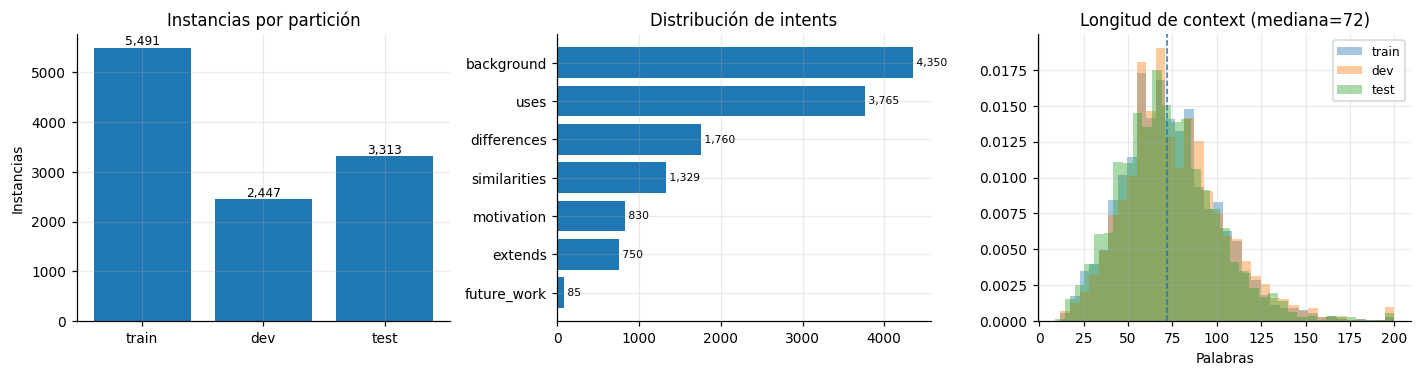

In [60]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))

# 1. Instancias por partición
vc = df.split_orig.value_counts().reindex(SPLITS)
ax[0].bar(vc.index, vc.values)
for i, v in enumerate(vc.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax[0].set_title("Instancias por partición")
ax[0].set_ylabel("Instancias")

# 2. Distribución de intents
vc_int = exp.intent.value_counts()
ax[1].barh(vc_int.index[::-1], vc_int.values[::-1])
for i, v in enumerate(vc_int.values[::-1]):
    ax[1].text(v, i, f" {v:,}", va="center", fontsize=7)
ax[1].set_title("Distribución de intents")

# 3. Longitud del contexto
for s in SPLITS:
    ax[2].hist(
        df[df.split_orig == s].n_words.clip(0, 200),
        bins=35,
        alpha=.4,
        density=True,
        label=s
    )

ax[2].axvline(df.n_words.median(), ls="--", lw=1)
ax[2].set_title(f"Longitud de context (mediana={df.n_words.median():.0f})")
ax[2].set_xlabel("Palabras")
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig01_caracterizacion_original.png", dpi=300, bbox_inches="tight")
plt.show()

#### Figura 2: cobertura de las nueve categorías

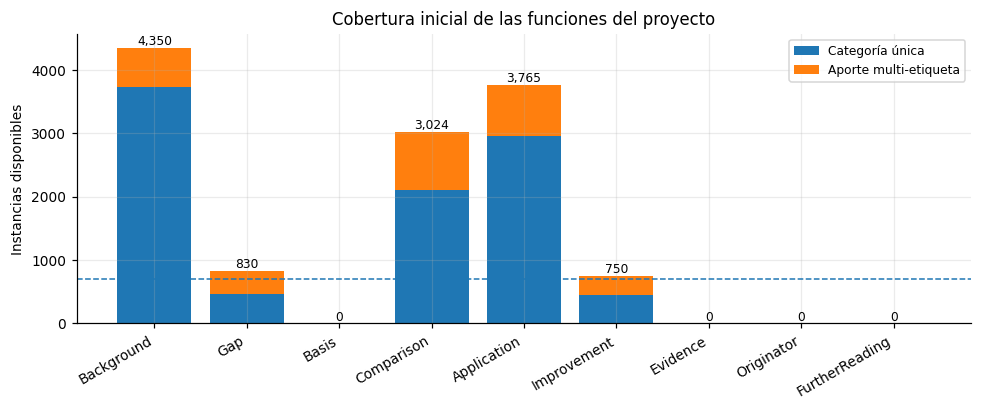

In [61]:
fig, ax = plt.subplots(figsize=(9, 3.8))

x = np.arange(len(TARGET_9))
puro = cov["puro_total"].values
extra = (cov["TOTAL"] - cov["puro_total"]).values

ax.bar(x, puro, label="Categoría única")
ax.bar(x, extra, bottom=puro, label="Aporte multi-etiqueta")

ax.axhline(META, ls="--", lw=1)

for i, total in enumerate(cov["TOTAL"].values):
    ax.text(i, total, f"{total:,}" if total else "0",
            ha="center", va="bottom", fontsize=8)

ax.set_xticks(x, TARGET_9, rotation=30, ha="right")
ax.set_ylabel("Instancias disponibles")
ax.set_title("Cobertura inicial de las funciones del proyecto")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig02_cobertura_inicial.png", dpi=300, bbox_inches="tight")
plt.show()

Figura 3: dataset resultante

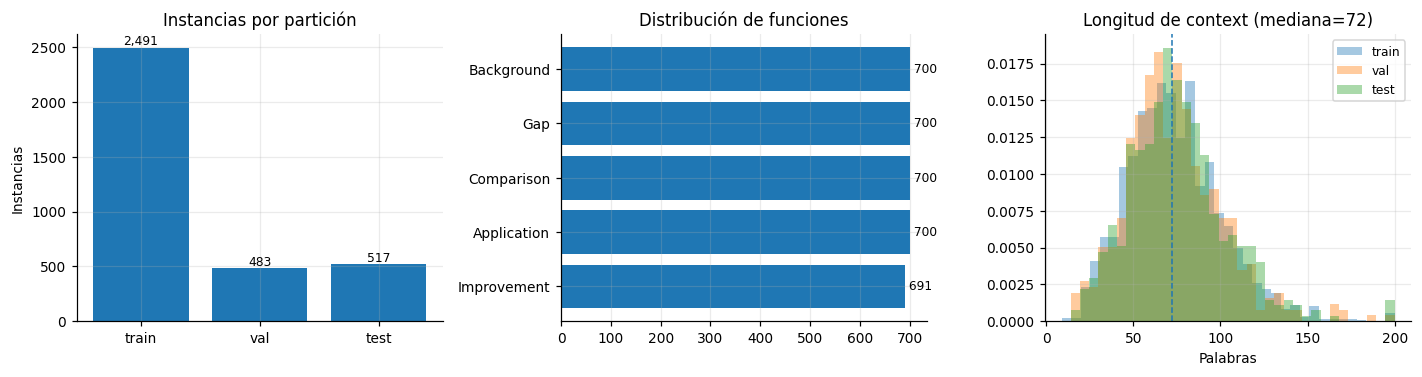

In [62]:
FINAL_LABELS = [
    "Background",
    "Gap",
    "Comparison",
    "Application",
    "Improvement"
]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))

# 1. Instancias por nueva partición
splits_final = ["train", "val", "test"]
vc = bal.split_proyecto.value_counts().reindex(splits_final)

ax[0].bar(vc.index, vc.values)
for i, v in enumerate(vc.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

ax[0].set_title("Instancias por partición")
ax[0].set_ylabel("Instancias")

# 2. Distribución de clases finales
vc_label = bal.label_proyecto.value_counts().reindex(FINAL_LABELS)

ax[1].barh(vc_label.index[::-1], vc_label.values[::-1])
for i, v in enumerate(vc_label.values[::-1]):
    ax[1].text(v, i, f" {v:,}", va="center", fontsize=8)

ax[1].set_title("Distribución de funciones")

# 3. Longitud del contexto
for s in splits_final:
    ax[2].hist(
        bal[bal.split_proyecto == s].n_words.clip(0, 200),
        bins=35,
        alpha=.4,
        density=True,
        label=s
    )

ax[2].axvline(bal.n_words.median(), ls="--", lw=1)
ax[2].set_title(f"Longitud de context (mediana={bal.n_words.median():.0f})")
ax[2].set_xlabel("Palabras")
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig03_caracterizacion_final.png", dpi=300, bbox_inches="tight")
plt.show()

####  intents originales por partición

In [63]:
tabla_original_informe = tab.copy()
tabla_original_informe

split_orig,train,dev,test,TOTAL
intent,,,,
background,2144,929,1277,4350
uses,1848,793,1124,3765
differences,836,420,504,1760
similarities,609,322,398,1329
motivation,433,185,212,830
extends,365,165,220,750
future_work,37,25,23,85


#### Funciones resultantes por partición.

In [64]:
tabla_final_informe = tabla[["train", "val", "test"]].copy()
tabla_final_informe["TOTAL"] = tabla_final_informe.sum(axis=1)
tabla_final_informe

split_proyecto,train,val,test,TOTAL
label_proyecto,,,,
Application,498,102,100,700
Background,498,89,113,700
Comparison,499,108,93,700
Gap,504,91,105,700
Improvement,492,93,106,691
